# NumPy基础：数组与向量化计算

NumPy，全称为Numerical Python，是Python中最重要的基础包之一，用于数值计算。许多提供科学功能的计算包使用NumPy的数组对象作为数据交换的标准接口语言。我所涵盖的关于NumPy的大部分知识也可以转移到pandas上。

这里有一些你会在NumPy中找到的东西：
- ndarray是一个高效的多维数组，提供快速的面向数组的算术运算和灵活的广播能力。
- 数学函数用于对整个数据数组进行快速操作而不必编写循环
- 用于将数组数据读写到磁盘以及处理内存映射文件的工具
- 线性代数、随机数生成和傅里叶变换能力
- 用于连接NumPy与用C、C++或FORTRAN编写的库的C API

因为NumPy提供了一个全面且文档良好的C API，所以将数据传递给用低级语言编写的外部库以及让外部库返回数据给Python作为NumPy数组都非常直接。这一特性使得Python成为封装遗留的C、C++或FORTRAN代码库的首选语言，并为它们提供了动态且易于访问的接口。

虽然NumPy本身并不提供建模或科学计算功能，但了解NumPy数组和面向数组的计算将有助于您更有效地使用具有数组计算语义的工具，如pandas。由于NumPy是一个很大的主题，我将在后面更深入地介绍许多高级NumPy特性，如广播（见附录A：高级NumPy）。这些高级特性中很多并不是跟随本书其余部分所必需的，但它们可能会帮助您更深入地了解Python中的科学计算。

对于大多数数据分析应用来说，我将重点关注的几个主要功能领域是：
- 快速基于数组的操作，用于数据清洗、子集和过滤、转换以及任何其他类型的计算
- 常见的数组算法，如排序、去重和集合操作
- 有效的描述性统计和聚合/总结数据
- 数据对齐和关系数据操作，用于合并和连接异构数据集
- 将条件逻辑表示为数组表达式而不是使用if-elif-else分支的循环
- 分组数据操作（聚合、转换和函数应用）

虽然NumPy为一般的数值数据处理提供了计算基础，但许多读者可能会希望使用pandas作为大多数统计或分析的基础，特别是在表格数据上。此外，pandas还提供了一些更具体的领域功能，如时间序列操作，这些在NumPy中是不存在的。
> Python中的数组导向计算可以追溯到1995年，当时Jim Hugunin创建了Numeric库。在接下来的十年里，许多科学编程社区开始使用Python进行数组编程，但到了2000年代初，库生态系统变得碎片化。2005年，Travis Oliphant能够将当时的Numeric和Numarray项目合并成NumPy项目，从而将社区团结在单一的数组计算框架周围。

NumPy对于Python中的数值计算如此重要的原因之一是因为它针对大型数据数组进行了优化设计。这有几个原因：
- NumPy内部将数据存储在连续的内存块中，独立于其他内置的Python对象。用C语言编写的NumPy算法库可以在不进行任何类型检查或其他开销的情况下操作这些内存。NumPy数组也比内置的Python序列使用更少的内存。
- NumPy操作可以对整个数组执行复杂的计算，无需使用Python循环，这对于大型序列来说可能会很慢。NumPy比常规的Python代码更快，因为它的基于C的算法避免了常规解释型Python代码中存在的开销。

为了让你了解性能差异，考虑一个包含一百万个整数的NumPy数组和相应的Python列表：

In [1]:
import numpy as np

my_arr = np.arange(1_000_000)

my_list = list(range(1_000_000))

现在让我们把每个序列乘以2：

In [2]:
%timeit my_arr2 = my_arr * 2

374 μs ± 1.07 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [3]:
%timeit my_list2 = [x * 2 for x in my_list]

26.4 ms ± 177 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


基于NumPy的算法通常比纯Python实现快10到100倍（或更多），并且使用的内存显著减少。

## NumPy的ndarray：多维数组对象

NumPy的一个关键特性是其多维数组对象，或称为ndarray，它是Python中用于大型数据集的快速、灵活的容器。数组使您能够使用类似于标量元素之间等效操作的语法对整个数据块执行数学运算。

为了让您了解NumPy如何以与内置Python对象上的标量值类似的语法启用批量计算，我首先导入NumPy并创建一个小数组：

In [4]:
import numpy as np

data = np.array([[1.5, -0.1, 3], [0, -3, 6.5]])
data

array([[ 1.5, -0.1,  3. ],
       [ 0. , -3. ,  6.5]])

然后我写带有数据的数学运算：

In [5]:
data * 10

array([[ 15.,  -1.,  30.],
       [  0., -30.,  65.]])

In [6]:
data + data

array([[ 3. , -0.2,  6. ],
       [ 0. , -6. , 13. ]])

在第一个例子中，所有的元素都乘以了10。在第二个例子中，数组中每个“单元格”的对应值被相加。
> 在本章及整本书中，我使用标准的NumPy约定，总是将import numpy as np。在你的代码中可以使用from numpy import *来避免写np.，但我建议不要养成这个习惯。NumPy命名空间很大，包含许多与内置Python函数（如min和max）名称冲突的函数。遵循这样的标准约定几乎总是个好主意。

ndarray是用于同质数据的通用多维容器；也就是说，所有元素必须是相同类型的。每个数组都有一个shape，一个表示每个维度大小的元组，以及一个dtype，一个描述数组数据类型的对象：

In [7]:
data.shape

(2, 3)

In [8]:
data.dtype

dtype('float64')

本章将介绍使用NumPy数组的基础知识，这应该足以让你跟随本书的其他部分。虽然对于许多数据分析应用来说，不需要对NumPy有深入的理解，但掌握面向数组的编程和思维是成为科学Python大师的关键步骤之一。
> 在书中，当你看到“数组”、“NumPy数组”或“ndarray”时，大多数情况下它们都指的是ndarray对象。

### 创建ndarray

创建数组最简单的方法是使用array函数。该函数接受任何类似序列的对象（包括其他数组），并产生一个包含传递数据的新NumPy数组。例如，列表是转换的一个好候选者：

In [9]:
data1 = [6, 7.5, 8, 0, 1]
arr1 = np.array(data1)
arr1

array([6. , 7.5, 8. , 0. , 1. ])

嵌套序列，例如等长列表的列表，将被转换为一个多维数组：

In [10]:
data2 = [[1, 2, 3, 4], [5, 6, 7, 8]]
arr2 = np.array(data2)
arr2

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

由于data2是一个列表的列表，NumPy数组arr2具有两个维度，其形状是根据数据推断出来的。我们可以通过检查ndim和shape属性来确认这一点：

In [11]:
arr2.ndim

2

In [12]:
arr2.shape

(2, 4)

除非明确指定（在ndarray的数据类型中讨论），numpy.array会尝试推断它创建数组的良好数据类型。数据类型存储在一个特殊的dtype元数据对象中；例如，在前两个示例中我们有：

In [13]:
arr1.dtype

dtype('float64')

In [14]:
arr2.dtype

dtype('int64')

除了numpy.array之外，还有多个其他函数用于创建新数组。例如，numpy.zeros和numpy.ones分别创建给定长度或形状的全0或全1数组。numpy.empty创建一个未初始化其值为任何特定值的数组。要使用这些方法创建更高维的数组，请传递一个形状元组：

In [15]:
np.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [16]:
np.zeros((3, 6))

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [17]:
np.empty((2, 3, 2))

array([[[0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.]]])

> **⚠️警告** 假设numpy.empty会返回一个全零数组是不安全的。这个函数返回的是未初始化的内存，因此可能包含非零的“垃圾”值。只有当你打算用数据填充新数组时，才应该使用这个函数。

numpy.arange是内置Python range函数的一个数组值版本：

In [18]:
np.arange(15)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

请参参见下表了解标准数组创建函数的简短列表。由于 NumPy 主要关注数值计算，如果未指定数据类型，在许多情况下默认会是 float64（浮点型）。

| 方法 | 描述 |
|-----|------|
| array | 将输入数据（列表、元组、数组或其他序列类型）转换为ndarray，可以通过推断数据类型或显式指定数据类型；默认情况下复制输入数据。 |
| asarray | 将输入转换为ndarray，但如果输入已经是ndarray则不复制 |
| arange | 与内置range类似，但返回的是ndarray而不是列表 |
| ones, ones_like | 生成一个给定形状和数据类型的全1数组；ones_like接受另一个数组并生成相同形状和数据类型的全1数组 |
| zeros, zeros_like | 类似于ones和ones_like，但产生的是全零数组 |
| empty, empty_like | 通过分配新内存创建新的数组，但不要填充任何值，如1和0 |
| full, full_like | 生成一个给定形状和数据类型的数组，所有值都设置为指定的“填充值”；full_like接受另一个数组并生成相同形状和数据类型的填充数组。 |
| eye, identity | 创建一个N×N的单位矩阵（对角线上是1，其他地方都是0） |

### ndarray的数据类型

数据类型或dtype是一个特殊对象，它包含信息（或元数据，关于数据的数据），ndarray需要这些信息来将一块内存解释为特定类型的数据：

In [19]:
arr1 = np.array([1, 2, 3], dtype=np.float64)
arr2 = np.array([1, 2, 3], dtype=np.int32)

In [20]:
arr1.dtype

dtype('float64')

In [21]:
arr2.dtype

dtype('int32')

数据类型是NumPy灵活性的一个来源，用于与其他系统中的数据进行交互。在大多数情况下，它们直接映射到底层的磁盘或内存表示上，这使得能够将二进制数据流写入磁盘，并且能够连接到低级语言（如C或FORTRAN）编写的代码。数值数据类型的命名方式相同：一个类型名称，如float或int，后面跟着一个数字表示每个元素的字节数。标准的双精度浮点值（在Python的float对象中底层使用的）占用8个字节或64位。因此，这种类型在NumPy中被称为float64。请参见表4.2以获取NumPy支持的数据类型的完整列表。
> 不用担心记忆NumPy数据类型，特别是如果你是一个新用户。通常你只需要关心你正在处理的数据的一般类型，无论是浮点型、复数型、整数型、布尔型、字符串还是一般的Python对象。当你需要更控制数据在内存和磁盘上的存储方式时，尤其是大型数据集，了解你对存储类型的控制权是很好的。

| 类型 | 类型代码 | 描述 |
|-----|---------|------|
| int8, uint8 | i1, u1 | 有符号和无符号的8位（1字节）整数类型 |
| int16, uint16 | i2, u2 | 有符号和无符号的16位整数类型 |
| int32, uint32 | i4, u4 | 有符号和无符号的32位整数类型 |
| int64, uint64 | i8, u8 | 有符号和无符号的64位整数类型 |
| float16 | f2 | 半精度浮点数 |
| float32 | f4  f | 标准单精度浮点；与C语言中的float兼容 |
| float64 | f8 / d | 标准双精度浮点数；与C语言中的double和Python中的float对象兼容 |
| float128 | f16 / g | 扩展精度浮点数 |
| complex64, complex128, complex256 | c8, c16, c32 | 由两个32、64或128浮点数表示的复数 |
| bool | ? | 存储True和False值的布尔类型 |
| object | O |  Python对象类型；一个值可以是任何Python对象 |
| string_ | S | 固定长度ASCII字符串类型（每个字符1字节）；例如，要创建一个长度为10的字符串数据类型，使用'S10' |
| unicode_ | U | 固定长度Unicode类型（字节数平台特定）；与string_的规范语义相同（例如，‘U10’） |

> 有符号和无符号整数类型，许多读者可能不熟悉这个术语。有符号整数可以表示正数和负数，而无符号整数只能表示非零整数。例如，int8（有符号8位整数）可以表示从-128到127（包括）的整数，而uint8（无符号8位整数）可以表示0到255之间的整数。

可以使用ndarray的astype方法显式地将数组从一种数据类型转换为另一种数据类型：

In [22]:
arr = np.array([1, 2, 3, 4, 5])
arr.dtype

dtype('int64')

In [23]:
float_arr = arr.astype(np.float64)
float_arr

array([1., 2., 3., 4., 5.])

In [ ]:
float_arr.dtype


dtype('float64')

在这个例子中，整数被转换为浮点数。如果我把一些浮点数转换成整数类型，小数部分将被截断：

In [25]:
arr = np.array([3.7, -1.2, -2.6, 0.5, 12.9, 10.1])
arr

array([ 3.7, -1.2, -2.6,  0.5, 12.9, 10.1])

In [26]:
arr.astype(np.int32)

array([ 3, -1, -2,  0, 12, 10], dtype=int32)

如果你有一个代表数字的字符串数组，你可以使用astype来将它们转换为数值形式：

In [32]:
numeric_strings = np.array(['1.25', '-9.6', '42'], dtype=np.bytes_)
numeric_strings.astype(float)


array([ 1.25, -9.6 , 42.  ])

如果由于某种原因（比如字符串不能转换为float64）导致类型转换失败，将会引发ValueError。以前我有点懒，直接写float而不是np.float64；NumPy将Python类型映射到它自己的等效数据类型。

你还可以使用另一个数组的dtype属性：

In [33]:
int_array = np.arange(10)
calibers = np.array([.22, .270, .357, .380, .44, .50], dtype=np.float64)

int_array.astype(calibers.dtype)

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

还有一些简写类型的代码字符串可以用来指代dtype：

In [34]:
zeros_uint32 = np.zeros(8, dtype="u4")
zeros_uint32

array([0, 0, 0, 0, 0, 0, 0, 0], dtype=uint32)

> 调用astype总是创建一个新数组（数据的副本），即使新数据类型与旧数据类型相同。

### 使用NumPy数组的数学运算

数组之所以重要，是因为它们可以让你在不编写任何循环的情况下对数据进行批量操作。NumPy用户称之为向量化。相同大小的数组之间的任何算术运算都会逐元素应用该操作：

In [35]:
arr = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
arr

array([[1., 2., 3.],
       [4., 5., 6.]])

In [36]:
arr * arr

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [37]:
arr - arr

array([[0., 0., 0.],
       [0., 0., 0.]])

标量与数组元素的算术运算会将标量参数传播到数组的每个元素：

In [38]:
1 / arr

array([[1.        , 0.5       , 0.33333333],
       [0.25      , 0.2       , 0.16666667]])

In [39]:
arr * 2

array([[ 2.,  4.,  6.],
       [ 8., 10., 12.]])

相同大小的数组之间的比较产生布尔数组：

In [40]:
arr2 = np.array([[0.0, 4.0, 1.0], [7.0, 2.0, 12.0]])
arr2

array([[ 0.,  4.,  1.],
       [ 7.,  2., 12.]])

In [41]:
arr2 > arr

array([[False,  True, False],
       [ True, False,  True]])

> 评估不同大小数组之间的运算称为广播，将在附录A：高级NumPy中更详细地讨论。对于本书的大部分内容来说，深入理解广播并不是必需的。

### 基本索引和切片

NumPy数组索引是一个深入的话题，因为有许多方法你可能想要选择你数据的一个子集或单个元素。一维数组很简单；从表面上看，它们的行为类似于Python列表：

In [42]:
arr = np.arange(10)
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [43]:
arr[5]

np.int64(5)

In [44]:
arr[5:8]

array([5, 6, 7])

In [45]:
arr[5:8] = 12
arr

array([ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9])

如你所见，如果你将一个标量值分配给一个切片，例如arr[5:8] = 12，该值将被传播（或从此称为广播）到整个选择中。

> 与Python内置列表的一个重要区别是数组切片是原始数组的视图。这意味着数据不会被复制，对视图的任何修改都会反映在源数组中。

为了说明这一点，我首先创建一个arr的切片：

In [46]:
arr_slice = arr[5:8]
arr_slice

array([12, 12, 12])

现在，当我在arr_slice中更改值时，这些变更会反映在原始数组arr中：

In [47]:
arr_slice[1] = 12345

arr

array([    0,     1,     2,     3,     4,    12, 12345,    12,     8,
           9])

“裸”切片[:]将分配给数组中的所有值：

In [48]:
arr_slice[:] = 64
arr

array([ 0,  1,  2,  3,  4, 64, 64, 64,  8,  9])

如果你对NumPy还不熟悉，你可能会对此感到惊讶，特别是如果你使用过其他更积极地复制数据的数组编程语言。由于NumPy被设计成能够处理非常大的数组，你可以想象如果NumPy坚持总是复制数据，那么性能和内存问题将会出现。

> 如果你想要一个数组的切片副本而不是视图，你需要显式地复制数组——例如，arr[5:8].copy()。正如你将会看到的，pandas也是这么做的。

在更高维的数组中，您有更多的选择。在二维数组中，每个索引处的元素不再是标量，而是一维数组：

In [49]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

arr2d[2]

array([7, 8, 9])

因此，可以递归地访问单个元素。但这样做有点麻烦，所以你可以传递一个逗号分隔的索引列表来选择单个元素。所以这些是等效的：

In [50]:
arr2d[0][2]

np.int64(3)

In [51]:
arr2d[0, 2]

np.int64(3)

在多维数组中，如果您省略后面的索引，返回的对象将是一个低维的ndarray，它由沿更高维度排列的所有数据组成。所以在2×2×3数组arr3d中：

In [52]:
arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])

arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

arr3d[0]是一个2×3的数组：

In [53]:
arr3d[0]

array([[1, 2, 3],
       [4, 5, 6]])

标量和数组都可以赋值给arr3d[0]：

In [54]:
old_values = arr3d[0].copy()
arr3d[0] = 42
arr3d

array([[[42, 42, 42],
        [42, 42, 42]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [55]:
arr3d[0] = old_values
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

同样地，arr3d[1, 0] 会返回所有以（1, 0）开头的索引值，形成一个一维数组：

In [56]:
arr3d[1, 0]

array([7, 8, 9])

这个表达式等同于我们分两步进行索引：

In [57]:
x = arr3d[1]

x

array([[ 7,  8,  9],
       [10, 11, 12]])

In [58]:
x[0]

array([7, 8, 9])

请注意，在所有这些情况下，如果选择了数组的子部分，返回的数组都是视图。

> 这种多维索引语法对NumPy数组有效，但对常规Python对象（如列表的列表）无效。

#### 使用切片进行索引

像Python列表这样的一维对象一样，ndarray可以使用熟悉的语法进行切片：

In [59]:
arr

array([ 0,  1,  2,  3,  4, 64, 64, 64,  8,  9])

In [60]:
arr[1:6]

array([ 1,  2,  3,  4, 64])

考虑之前的二维数组arr2d。对这个数组的切片有点不同：

In [61]:
arr2d

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [62]:
arr2d[:2]

array([[1, 2, 3],
       [4, 5, 6]])

如你所见，它沿着第一个轴（轴0）进行了切片。因此，切片沿一个轴选择了一组元素。将表达式arr2d[:2]读作“选择arr2d的前两行”是有帮助的。

你可以像传递多个索引一样传递多个切片：

In [63]:
arr2d[:2, 1:]

array([[2, 3],
       [5, 6]])

像这样切片时，你总是获得相同维数的数组视图。通过混合整数索引和切片，你可以得到低维度的切片。

例如，我可以选择第二行但只选择前两列，如下所示：

In [65]:
lower_dim_slice = arr2d[1, :2]

lower_dim_slice

array([4, 5])

在这里，虽然arr2d是二维的，但lower_dim_slice是一维的，其形状是一个只有一个轴大小的元组：

In [66]:
lower_dim_slice.shape

(2,)

同样地，我可以选择第三列但只有前两行，如下所示：

In [67]:
arr2d[:2, 2]

array([3, 6])

请注意，单独的冒号表示取整个轴，因此您可以通过执行以下操作来仅切片更高维度的轴：

In [68]:
arr2d[:, :1]

array([[1],
       [4],
       [7]])

当然，对切片表达式赋值就是对整个选择进行赋值：

In [69]:
arr2d[:2, 1:] = 0

arr2d

array([[1, 0, 0],
       [4, 0, 0],
       [7, 8, 9]])

### 布尔索引

让我们考虑一个例子，我们有一些数据在一个数组中，以及一个有重复名称的数组：

In [74]:
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])

data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2], [-12, -4], [3, 4]])

假设每个名称对应数据数组中的一行，我们想要选择所有与相应名称“Bob”匹配的行。像算术运算一样，数组的比较（例如==）也是向量化操作。因此，将名称与字符串“Bob”进行比较会产生一个布尔数组：

In [75]:
names == "Bob"

array([ True, False, False,  True, False, False, False])

这个布尔数组可以在索引数组时传递：

In [76]:
data[names == "Bob"]

array([[4, 7],
       [0, 0]])

布尔数组的长度必须与其索引的数组轴长度相同。您甚至可以将布尔数组与切片或整数（或整数序列；稍后详细介绍）混合使用。

在这些示例中，我从名字等于“Bob”的行中选择，并且也索引列：

In [77]:
data[names == "Bob", 1:]

array([[7],
       [0]])

In [78]:
data[names == "Bob", 1]

array([7, 0])

要选择除了“Bob”之外的所有内容，你可以使用 != 或者使用 ~ 来否定条件：

In [80]:
names != "Bob"

array([False,  True,  True, False,  True,  True,  True])

In [81]:
~(names == "Bob")

array([False,  True,  True, False,  True,  True,  True])

In [82]:
data[~(names == "Bob")]

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

当你想要反转一个由变量引用的布尔数组时，~ 运算符可能会很有用：

In [83]:
cond = names == "Bob"

data[~cond]

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

要选择三个名称中的两个来组合多个布尔条件，请使用布尔算术运算符如&（与）和|（或）：

In [84]:
mask = (names == "Bob") | (names == "Will")
mask

array([ True, False,  True,  True,  True, False, False])

In [85]:
data[mask]

array([[ 4,  7],
       [-5,  6],
       [ 0,  0],
       [ 1,  2]])

通过布尔索引从数组中选择数据并将结果分配给新变量时，即使返回的数组没有变化，也会始终创建数据的副本。
> **注意** Python的关键字and和or不适用于布尔数组。请改用&（与）和|（或）。

使用布尔数组设置值是通过将右侧的值或多个值替换到布尔数组的值为True的位置来实现的。要将数据中的所有负值设置为0，我们只需执行：

In [87]:
data[data < 0] = 0
data

array([[4, 7],
       [0, 2],
       [0, 6],
       [0, 0],
       [1, 2],
       [0, 0],
       [3, 4]])

您还可以使用一维布尔数组设置整行或整列：

In [88]:
data[names != "Joe"] = 7
data

array([[7, 7],
       [0, 2],
       [7, 7],
       [7, 7],
       [7, 7],
       [0, 0],
       [3, 4]])

我们稍后将会看到，在pandas中处理二维数据非常方便。

### 花式索引

花式索引是NumPy采用的一个术语，用于描述使用整数数组进行索引。假设我们有一个8×4的数组：

In [89]:
arr = np.zeros((8, 4))
for i in range(8):
    arr[i] = i
arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

要按特定顺序选择行的一个子集，可以简单地传递一个整数列表或ndarray指定所需的顺序：

In [90]:
arr[[4, 3, 0, 6]]

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

希望这段代码实现了你的预期！使用负索引可以从末尾选择行：

In [91]:
arr[[-3, -5, -7]]

array([[5., 5., 5., 5.],
       [3., 3., 3., 3.],
       [1., 1., 1., 1.]])

传递多个索引数组会执行略有不同的操作；它会选择一个与每个索引元组相对应的一维元素数组：

In [92]:
arr = np.arange(32).reshape((8, 4))
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [93]:
arr[[1, 5, 7, 2], [0, 3, 1, 2]]

array([ 4, 23, 29, 10])

这里选择了元素(1, 0)、(5, 3)、(7, 1)和(2, 2)。使用与轴数一样多的整数数组进行花式索引的结果始终是一维的。

在这种情况下，花式索引的行为与一些用户（包括我自己）可能期望的有些不同，即通过选择矩阵的行和列的一个子集来形成的矩形区域。这里有一种方法可以得到这个效果：

In [96]:
arr[[1, 5, 7, 2]][:, [0, 3, 1, 2]]

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

请注意，与切片不同，花式索引在将结果分配给新变量时总是复制数据到新数组中。如果您使用花式索引分配值，则索引的值将被修改：

In [97]:
arr[[1, 5, 7, 2], [0, 3, 1, 2]]

array([ 4, 23, 29, 10])

In [99]:
arr[[1, 5, 7, 2], [0, 3, 1, 2]] = 0
arr

array([[ 0,  1,  2,  3],
       [ 0,  5,  6,  7],
       [ 8,  9,  0, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22,  0],
       [24, 25, 26, 27],
       [28,  0, 30, 31]])

### 数组转置和轴交换

转置是一种特殊的重塑形式，它同样返回对底层数据的视图而不复制任何内容。数组具有转置方法和特殊的T属性：

In [100]:
arr = np.arange(15).reshape((3, 5))
arr

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [101]:
arr.T

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

在进行矩阵计算时，您可能会经常这样做——例如，在使用numpy.dot计算内矩阵积时：

In [103]:
arr = np.array([[0, 1, 0], [1, 2, -2], [6, 3, 2], [-1, 0, -1], [1, 0, 1]])
arr

array([[ 0,  1,  0],
       [ 1,  2, -2],
       [ 6,  3,  2],
       [-1,  0, -1],
       [ 1,  0,  1]])

In [104]:
np.dot(arr.T, arr)

array([[39, 20, 12],
       [20, 14,  2],
       [12,  2, 10]])

@中缀运算符是另一种进行矩阵乘法的途径：

In [105]:
arr.T @ arr

array([[39, 20, 12],
       [20, 14,  2],
       [12,  2, 10]])

使用 .T 进行简单的转置是交换轴的一个特例。ndarray 有一个名为 swapaxes 的方法，该方法接受一对轴号并将指定的轴进行交换以重新排列数据：

In [106]:
arr

array([[ 0,  1,  0],
       [ 1,  2, -2],
       [ 6,  3,  2],
       [-1,  0, -1],
       [ 1,  0,  1]])

In [107]:
arr.swapaxes(0, 1)

array([[ 0,  1,  6, -1,  1],
       [ 1,  2,  3,  0,  0],
       [ 0, -2,  2, -1,  1]])

## 伪随机数生成

numpy.random 模块补充了内置的 Python random 模块，提供了用于高效生成来自多种概率分布的样本值整数数组的函数。例如，您可以使用 numpy.random.standard_normal 从标准正态分布获得一个 4×4 的样本数组：

In [108]:
samples = np.random.standard_normal((4, 4))
samples

array([[ 0.13573128, -0.45182688,  0.02109684,  1.47831367],
       [-0.36700435,  0.42880806,  1.0389764 ,  0.64695527],
       [ 1.03834476, -1.44453042,  0.12984106,  0.92539711],
       [ 0.29460988,  0.55954283,  1.41089435,  0.01985843]])

相比之下，Python的内置随机模块一次只抽取一个值。正如这个基准测试所示，numpy.random在生成非常大的样本时速度要快上一个数量级以上：

In [109]:
from random import normalvariate

N = 1000000
%timeit samples = [normalvariate(0, 1) for _ in range(N)]
%timeit np.random.standard_normal(N)

386 ms ± 1.65 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
19.3 ms ± 48.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


这些随机数并非真正的随机（而是伪随机），而是由一个可配置的随机数生成器生成的，该生成器确定性地决定创建哪些值。像numpy.random.standard_normal这样的函数使用numpy.random模块的默认随机数生成器，但您的代码可以配置为使用一个显式的生成器：

In [112]:
rng = np.random.default_rng(seed=12345)

data = rng.standard_normal((2, 3))

data

array([[-1.42382504,  1.26372846, -0.87066174],
       [-0.25917323, -0.07534331, -0.74088465]])

seed参数决定了生成器的初始状态，每次使用rng对象生成数据时状态都会改变。生成器对象rng还与其他可能使用numpy.random模块的代码隔离：

In [113]:
type(rng)

numpy.random._generator.Generator

请参阅下表，了解随机生成器对象（如rng）上可用的部分方法列表。我将使用上面创建的rng对象在本书余下部分生成随机数据。

| 方法 | 描述 |
|-----|-----|
| permutation | 返回一个序列的随机排列，或者返回一个排列范围 |
| shuffle | 原地随机置换一个序列 |
| uniform | 从均匀分布中抽取样本 |
| integers | 从给定的低到高范围中抽取随机整数 |
| standard_normal | 从均值为0、标准差为1的正态分布中抽取样本 |
| binomial | 从二项分布中抽取样本 |
| normal | 从正态（高斯）分布中抽取样本 |
| beta | 从贝塔分布中抽取样本 |
| chisquare | 从卡方分布中抽取样本 |
| gamma | 从伽马分布中抽取样本 |
| uniform | 从均匀分布[0, 1)中抽取样本 |


## 通用函数：快速逐元素数组函数

通用函数（ufunc）是对数组中的数据进行逐元素操作的函数。你可以将它们视为对简单函数的快速向量化包装器，这些函数接受一个或多个标量值并产生一个或多个标量结果。

许多ufunc是简单的逐元素变换，如numpy.sqrt或numpy.exp：

In [114]:
arr = np.arange(10)
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [115]:
np.sqrt(arr)

array([0.        , 1.        , 1.41421356, 1.73205081, 2.        ,
       2.23606798, 2.44948974, 2.64575131, 2.82842712, 3.        ])

In [116]:
np.exp(arr)

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

这些被称为一元ufuncs。其他函数，例如numpy.add或numpy.maximum，接受两个数组（因此是二元ufuncs）并返回一个作为结果的单个数组：

In [118]:
x = rng.standard_normal(8)
x

array([-0.46695317, -0.06068952,  0.78884434, -1.25666813,  0.57585751,
        1.39897899,  1.32229806, -0.29969852])

In [119]:
y = rng.standard_normal(8)
y

array([ 0.90291934, -1.62158273, -0.15818926,  0.44948393, -1.34360107,
       -0.08168759,  1.72473993,  2.61815943])

In [120]:
np.maximum(x, y)

array([ 0.90291934, -0.06068952,  0.78884434,  0.44948393,  0.57585751,
        1.39897899,  1.72473993,  2.61815943])

在这个例子中，numpy.maximum计算了x和y中每个元素的最大值。

虽然不常见，但ufunc可以返回多个数组。numpy.modf就是一个例子：它是内置Python math.modf的向量化版本，它返回一个浮点数数组的分数部分和整数部分：

In [121]:
arr = rng.standard_normal(7) * 5
arr

array([ 3.88680672,  4.14316598, -4.79494157, -6.04694143, -7.06146007,
        2.70773415,  3.75969698])

In [122]:
remainers, whole_parts = np.modf(arr)
remainers

array([ 0.88680672,  0.14316598, -0.79494157, -0.04694143, -0.06146007,
        0.70773415,  0.75969698])

In [123]:
whole_parts

array([ 3.,  4., -4., -6., -7.,  2.,  3.])

ufuncs接受一个可选的out参数，允许它们将结果分配到一个现有的数组中，而不是创建一个新的数组：

In [124]:
arr

array([ 3.88680672,  4.14316598, -4.79494157, -6.04694143, -7.06146007,
        2.70773415,  3.75969698])

In [126]:
out = np.zeros_like(arr)
np.add(arr, 1)

array([ 4.88680672,  5.14316598, -3.79494157, -5.04694143, -6.06146007,
        3.70773415,  4.75969698])

In [127]:
np.add(arr, 1, out=out)
out

array([ 4.88680672,  5.14316598, -3.79494157, -5.04694143, -6.06146007,
        3.70773415,  4.75969698])

一元ufuncs：
| 函数 | 描述 |
|-----|------|
| abs, fabs | 计算整数、浮点数或复数的绝对值（逐元素） |
| sqrt | 计算每个元素的平方根（相当于arr ** 0.5） |
| square | 计算每个元素的平方（相当于arr ** 2） |
| exp | 计算每个元素的指数$e^x$ |
| log, log10, log2, log1p | 自然对数（底数为e）、以10为底的对数、以2为底的对数以及log(1 + x) |
| sign | 计算每个元素的符号：1（正数），0（零）或-1（负数） |
| ceil | 计算每个元素的向上取整（即大于或等于该数的最小整数）|
| floor | 计算每个元素的向下取整（即小于或等于每个元素的最大整数） |
| rint | 将元素四舍五入到最接近的整数，同时保留数据类型 |
| modf | 将数组的分数部分和整数部分作为两个单独的数组返回 |
| isnan | 返回布尔数组，指示每个值是否为NaN（非数字） |
isfinite, isinf | 返回布尔数组，指示每个元素是有限的（非无穷大、非NaN）还是无限的。|
| cos, cosh, sin, sinh, tan, tanh | 正弦、余弦和双曲正弦、双曲余弦函数 |
| arccos, arccosh, arcsin, arcsinh, arctan, arctanh | 反三角函数 |
| logical_not | 逐元素计算not x的真值（等同于~arr）|

二元ufuncs：
| 函数 | 描述 |
|------|-----|
| add | 对数组相应的元素求和 |
| subtract | 从第一个数组中减去第二个数组的元素 |
| multiply | 数组元素相乘 |
| divide, floor_divide | 除法或向下取整（舍去余数） |
| power | 将第一个数组中的元素提升到第二个数组中指示的幂次 |
| maximum, fmax | 逐元素最大值；fmax忽略NaN |
| minimum, fmin | 逐元素最小值；fmin忽略NaN |
| mod | 逐元素模数（除法余数） |
| copysign | 将第二个参数中的值复制到第一个参数中的值 |
| greater, greater_equal, less, less_equal, equal, not_equal | 执行逐元素比较，产生布尔数组（相当于中缀运算符 >、>=、<、<=、==、!=）|
| logical_and | 计算AND（&）逻辑运算的逐元素真值 |
| logical_or | 计算OR（|）逻辑运算的逐元素真值 |
| logical_xor | 计算XOR（^）逻辑运算的逐元素真值 |


## 面向数组编程

使用NumPy数组可以让你用简洁的数组表达式来表达许多种数据处理任务，这些任务可能原本需要编写循环。这种用数组表达式替换显式循环的做法被一些人称为向量化。一般来说，向量化的数组操作通常会比它们的纯Python等价物快得多，这在任何类型的数值计算中都有最大的影响。稍后，在附录A：高级NumPy中，我将解释广播，这是一种强大的向量化计算方法。

作为一个简单的例子，假设我们希望评估函数sqrt(x^2 + y^2)在规则网格上的值。numpy.meshgrid函数接受两个一维数组，并产生两个二维矩阵，对应于两个数组中所有对的(x, y)：

In [128]:
points = np.arange(-5, 5, 0.01)
points

array([-5.0000000e+00, -4.9900000e+00, -4.9800000e+00, -4.9700000e+00,
       -4.9600000e+00, -4.9500000e+00, -4.9400000e+00, -4.9300000e+00,
       -4.9200000e+00, -4.9100000e+00, -4.9000000e+00, -4.8900000e+00,
       -4.8800000e+00, -4.8700000e+00, -4.8600000e+00, -4.8500000e+00,
       -4.8400000e+00, -4.8300000e+00, -4.8200000e+00, -4.8100000e+00,
       -4.8000000e+00, -4.7900000e+00, -4.7800000e+00, -4.7700000e+00,
       -4.7600000e+00, -4.7500000e+00, -4.7400000e+00, -4.7300000e+00,
       -4.7200000e+00, -4.7100000e+00, -4.7000000e+00, -4.6900000e+00,
       -4.6800000e+00, -4.6700000e+00, -4.6600000e+00, -4.6500000e+00,
       -4.6400000e+00, -4.6300000e+00, -4.6200000e+00, -4.6100000e+00,
       -4.6000000e+00, -4.5900000e+00, -4.5800000e+00, -4.5700000e+00,
       -4.5600000e+00, -4.5500000e+00, -4.5400000e+00, -4.5300000e+00,
       -4.5200000e+00, -4.5100000e+00, -4.5000000e+00, -4.4900000e+00,
       -4.4800000e+00, -4.4700000e+00, -4.4600000e+00, -4.4500000e+00,
      

In [129]:
xs, ys = np.meshgrid(points, points)

In [130]:
xs

array([[-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       ...,
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99]],
      shape=(1000, 1000))

In [131]:
ys

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]],
      shape=(1000, 1000))

现在，评估函数就是写出与两点相同的表达式：

In [132]:
z = np.sqrt(xs**2 + ys**2)
z

array([[7.07106781, 7.06400028, 7.05693985, ..., 7.04988652, 7.05693985,
        7.06400028],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       ...,
       [7.04988652, 7.04279774, 7.03571603, ..., 7.0286414 , 7.03571603,
        7.04279774],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568]], shape=(1000, 1000))

作为第9章：绘图与可视化的预览，我使用matplotlib来创建这个二维数组的可视化效果：

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_8727/2602352797.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")


Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

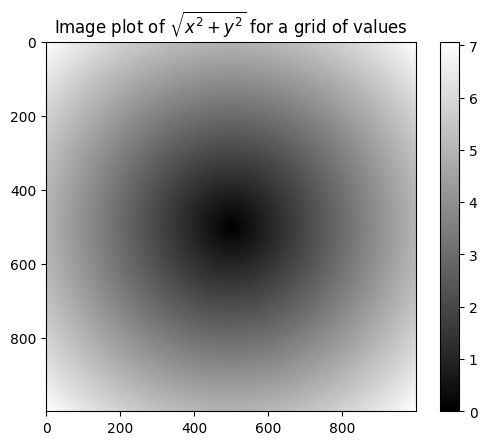

In [134]:
from matplotlib import pyplot as plt
plt.imshow(z, cmap=plt.cm.gray)
plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

> 向量化一词用于描述其他一些计算机科学概念，但在本书中我用它来描述一次性对整个数据数组进行的操作，而不是使用Python的for循环逐个值进行。

### 将条件逻辑表达为数组操作

numpy.where函数是三元表达式x if condition else y的向量化版本。假设我们有一个布尔数组和两个值数组：

In [135]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

假设我们想要在cond中的相应值为True时从xarr中取一个值，否则从yarr中取一个值。一个列表推导式来完成这个任务可能看起来像这样：

In [136]:
result = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]
result

[np.float64(1.1),
 np.float64(2.2),
 np.float64(1.3),
 np.float64(1.4),
 np.float64(2.5)]

这存在多个问题。首先，对于大型数组来说速度不会很快（因为所有的工作都是在解释的Python代码中完成的）。其次，它不适用于多维数组。使用numpy.where可以用单个函数调用完成这个操作：

In [137]:
result = np.where(cond, xarr, yarr)
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

numpy.where的第二个和第三个参数不需要是数组；它们中的一个或两个可以是标量。在数据分析中，where的典型用途是基于另一个数组生成一个新的值数组。假设你有一个随机生成的数据矩阵，并且你想将所有正数替换为2，所有负数替换为-2。这是可以用numpy.where来实现的：

In [138]:
arr = rng.standard_normal((4, 4))
arr

array([[-0.65876032, -1.22867499,  0.25755777,  0.31290292],
       [-0.13081169,  1.26998312, -0.09296246, -0.06615089],
       [-1.10821447,  0.13595685,  1.34707776,  0.06114402],
       [ 0.0709146 ,  0.43365454,  0.27748366,  0.53025239]])

In [139]:
arr > 0

array([[False, False,  True,  True],
       [False,  True, False, False],
       [False,  True,  True,  True],
       [ True,  True,  True,  True]])

In [140]:
np.where(arr > 0, 2, -2)

array([[-2, -2,  2,  2],
       [-2,  2, -2, -2],
       [-2,  2,  2,  2],
       [ 2,  2,  2,  2]])

在使用numpy.where时，你可以将标量和数组结合起来。例如，我可以将所有arr中的正数值替换为常数2，如下所示：

In [141]:
np.where(arr > 0, 2, arr)

array([[-0.65876032, -1.22867499,  2.        ,  2.        ],
       [-0.13081169,  2.        , -0.09296246, -0.06615089],
       [-1.10821447,  2.        ,  2.        ,  2.        ],
       [ 2.        ,  2.        ,  2.        ,  2.        ]])

### 数学与统计方法

一组计算整个数组或沿轴数据统计信息的数学函数作为数组类的方法是可用的。你可以通过调用数组实例方法或使用顶层NumPy函数来使用聚合（有时称为归约）操作，如求和、均值和标准差（标准偏差）。当你使用NumPy函数，如numpy.sum时，你必须将你想要聚合的数组作为第一个参数传递。

我生成一些正态分布的随机数据并计算一些聚合统计数据：

In [142]:
arr = rng.standard_normal((5, 4))
arr

array([[ 0.53672097,  0.61835001, -0.79501746,  0.30003095],
       [-1.60270159,  0.26679883, -1.26162378, -0.07127081],
       [ 0.47404973, -0.41485376,  0.0977165 , -1.64041784],
       [-0.85725882,  0.68828179, -1.15452958,  0.65045239],
       [-1.38835995, -0.90738246, -1.09542531,  0.00714569]])

In [143]:
arr.mean()

np.float64(-0.37746472482018373)

In [144]:
np.mean(arr)

np.float64(-0.37746472482018373)

In [145]:
arr.sum()

np.float64(-7.549294496403674)

像mean和sum这样的函数有一个可选的axis参数，它计算给定轴上的统计数据，结果是一个维度少一维的数组：

In [146]:
arr.mean(axis=1)

array([ 0.16502112, -0.66719934, -0.37087634, -0.16826356, -0.84600551])

In [147]:
arr.sum(axis=0)

array([-2.83754967,  0.25119441, -4.20887963, -0.75405961])

这里的arr.mean(axis=1)表示“按列计算均值”，而arr.sum(axis=0)表示“按行计算总和”。

其他方法如cumsum和cumprod不会聚合，而是产生一个中间结果的数组：

In [148]:
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7])

arr.cumsum()

array([ 0,  1,  3,  6, 10, 15, 21, 28])

在多维数组中，累积函数如cumsum返回一个与原始数组大小相同的新数组，但是沿指定轴计算每个较低维切片的部分聚合：

In [149]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])

arr

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

表达式arr.cumsum(axis=0)计算沿行的累积和，而arr.cumsum(axis=1)计算沿列的和：

In [150]:
arr.cumsum(axis=0)

array([[ 0,  1,  2],
       [ 3,  5,  7],
       [ 9, 12, 15]])

In [151]:
arr.cumsum(axis=1)

array([[ 0,  1,  3],
       [ 3,  7, 12],
       [ 6, 13, 21]])

基本数组统计方法:
| 方法 | 描述 |
|-----|------|
| sum | 数组中所有元素或沿某一轴的总和；长度为零的数组的和为0 |
| mean | 算术平均数；对于长度为零的数组无效（返回NaN） |
| std, var | 标准差和方差 |
| min, max | 最小值和最大值 |
| argmin, argmax | 最小元素和最大元素的索引 |
| cumsum | 从0开始的元素累积和 |
| cumprod | 从1开始的元素的累积乘积 |

### 布尔数组方法

布尔值在前述方法中被强制转换为1（真）和0（假）。因此，sum通常被用作计算布尔数组中真值数量的一种手段：

In [152]:
arr = rng.standard_normal(100)

arr

array([ 5.34359903e-01, -1.06580785e+00, -1.81472740e-01,  1.62195180e+00,
       -3.17391946e-01, -8.15814967e-01,  3.86579017e-01, -2.23638926e-01,
       -7.01690809e-01, -1.79571318e+00,  8.18325622e-01, -5.71032902e-01,
        7.85525063e-04, -1.06364272e+00,  1.30171450e+00,  7.47872942e-01,
        9.80875909e-01, -1.10418688e-01,  4.67918531e-01,  8.90607150e-01,
        1.02300937e+00,  3.12383389e-01, -6.19046857e-02, -3.59479647e-01,
       -7.48643984e-01, -9.65478907e-01,  3.60034657e-01, -2.44552532e-01,
       -1.99585661e+00, -1.55247617e-01,  1.06383087e+00, -2.75171567e-01,
       -1.85333593e+00, -1.24341928e-01,  7.84974522e-01,  2.01998597e-01,
       -4.28074443e-01,  1.84828890e+00,  1.89995289e+00, -9.84250348e-02,
        8.13445440e-01,  3.92494389e-01,  7.81442900e-01,  1.45327152e+00,
        8.20186045e-01,  8.77053446e-02, -6.53505648e-01, -8.11886879e-01,
       -2.55381724e-02,  1.15818454e+00,  3.00520870e-01,  5.30566461e-02,
        2.57271524e-01,  

In [153]:
(arr > 0).sum()

np.int64(49)

In [154]:
(arr <= 0).sum()

np.int64(51)

表达式中的括号（arr > 0）.sum()是必需的，以便能够对arr > 0的临时结果调用sum()。

另外两种方法，any和all，对于布尔数组特别有用。any测试数组中是否有一个或多个值为True，而all检查每个值是否为True：

In [155]:
bools = np.array([True, False, True, False])
bools.any()

np.True_

In [156]:
bools.all()

np.False_

这些方法也适用于非布尔数组，其中非零元素被视为True。

### 排序

像Python内置的列表类型一样，NumPy数组可以使用sort方法就地排序：

In [157]:
arr = rng.standard_normal(6)

arr

array([ 1.27279553,  0.40589222, -0.05032522,  0.28931754,  0.17930568,
        1.39748056])

In [159]:
arr.sort()
arr

array([-0.05032522,  0.17930568,  0.28931754,  0.40589222,  1.27279553,
        1.39748056])

您可以通过传递要排序的轴号来就地对多维数组中的每个一维值部分沿该轴进行排序。在此示例数据中：

In [160]:
arr = rng.standard_normal((5, 3))

arr

array([[ 0.29204679,  0.63840567, -0.02788771],
       [ 1.37105185, -2.05280763,  0.38050908],
       [ 0.75539067, -1.15912585,  2.15031011],
       [-0.15027022, -0.16116428, -1.07944248],
       [ 0.87796618,  0.22446741, -0.59159345]])

arr.sort(axis=0) 对每一列内的值进行排序，而arr.sort(axis=1) 则对每一行内的值进行排序：

In [161]:
arr.sort(axis=0)

arr

array([[-0.15027022, -2.05280763, -1.07944248],
       [ 0.29204679, -1.15912585, -0.59159345],
       [ 0.75539067, -0.16116428, -0.02788771],
       [ 0.87796618,  0.22446741,  0.38050908],
       [ 1.37105185,  0.63840567,  2.15031011]])

In [162]:
arr.sort(axis=1)
arr

array([[-2.05280763, -1.07944248, -0.15027022],
       [-1.15912585, -0.59159345,  0.29204679],
       [-0.16116428, -0.02788771,  0.75539067],
       [ 0.22446741,  0.38050908,  0.87796618],
       [ 0.63840567,  1.37105185,  2.15031011]])

顶级方法numpy.sort返回一个排序后的数组副本（类似于Python内置函数sorted），而不是就地修改数组。例如：

In [163]:
arr2 = np.array([5, -10, 7, 1, 0, -3])
sorted_arr2 = np.sort(arr2)
sorted_arr2

array([-10,  -3,   0,   1,   5,   7])

有关使用NumPy排序方法的更多细节，以及间接排序等更高级的技术，请参见附录A：高级NumPy。与排序相关的其他几种数据操作（例如，按一个或多个列对数据表进行排序）也可以在pandas中找到。

### 唯一性及其他集合逻辑

NumPy 有一系列用于一维数组的集合操作。一个常用的操作是numpy.unique，它返回数组中排序后的唯一值：

In [164]:
names = np.array(["Bob", "Will", "Joe", "Bob", "Will", "Joe", "Joe"])

np.unique(names)

array(['Bob', 'Joe', 'Will'], dtype='<U4')

In [165]:
ints = np.array([3, 3, 3, 2, 2, 1, 1, 4, 4])
np.unique(ints)

array([1, 2, 3, 4])

对比numpy.unique和纯Python的替代方法：

In [166]:
sorted(set(names))

[np.str_('Bob'), np.str_('Joe'), np.str_('Will')]

在许多情况下，NumPy版本更快，并且返回一个NumPy数组而不是Python列表。

另一个函数numpy.in1d测试一个数组中的值是否存在于另一个数组中，返回一个布尔数组：

In [167]:
values = np.array([6, 0, 0, 3, 2, 5, 6])
np.in1d(values, [2, 3, 6])

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_8727/1293837718.py:2: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  np.in1d(values, [2, 3, 6])


array([ True, False, False,  True,  True, False,  True])

数组集合操作:

| 方法 | 描述 |
|-----|------|
| unique(x) | 计算x中排序的唯一元素 |
| intersect1d(x,y) | 计算x和y中排序后相同的元素 |
| union1d(x, y) | 计算元素的排序并集 |
| in1d(x, y) | 计算一个布尔数组，指示x中的每个元素是否包含在y中 |
| setdiff1d(x, y) | 集合差集，x中不在y中的元素 |
| setxord1d(x, y) | 设置对称差集；存在于任一数组中但不在两个数组中的元素 |

## 数组文件输入输出

NumPy能够以某种文本或二进制格式将数据保存到磁盘并从磁盘中加载。在本节中，我只讨论NumPy的内置二进制格式，因为大多数用户会更喜欢pandas和其他工具来加载文本或表格数据（更多信息请参见第6章：数据加载、存储和文件格式）。

numpy.save和numpy.load是用于高效保存和加载磁盘上数组数据的两个主力函数。数组默认以未压缩的原始二进制格式保存，文件扩展名为.npy：

In [168]:
arr = np.arange(10)
np.save('some_array', arr)

如果文件路径不以 .npy 结尾，将追加扩展名。然后可以使用 numpy.load 加载磁盘上的数组：

In [169]:
np.load('some_array.npy')

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

你可以使用numpy.savez将多个数组保存到一个未压缩的归档文件中，并将数组作为关键字参数传递：

In [170]:
np.savez('array_archive.npz', a=arr, b=arr*2)

当加载一个.npz文件时，你会得到一个类似字典的对象，它延迟加载各个数组：

In [172]:
arch = np.load('array_archive.npz')

arch.get('b')

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

如果你的数据压缩得很好，你可能希望使用numpy.savez_compressed代替：

In [174]:
np.savez_compressed('array_compressed.npz', a=arr, b=arr*2)

arch = np.load('array_compressed.npz')
arch['b']


array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

## 线性代数

线性代数操作，如矩阵乘法、分解、行列式和其他方阵数学，是许多数组库的重要组成部分。使用*运算符将两个二维数组相乘是一个元素级的乘积，而矩阵乘法需要使用点函数或@中缀运算符。点既是numpy命名空间中的一个数组方法，也是一个用于执行矩阵乘法的函数：

In [175]:
x = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
y = np.array([[6.0, 23.0], [-1.0, 7.0], [8.0, 9.0]])

x.dot(y)

array([[ 28.,  64.],
       [ 67., 181.]])

x.dot(y)等同于np.dot(x, y)：

In [176]:
np.dot(x, y)

array([[ 28.,  64.],
       [ 67., 181.]])

一个二维数组和一个适当大小的一维数组的矩阵乘积会得到一个一维数组：

In [177]:
x @ np.ones(3)

array([ 6., 15.])

numpy.linalg有一组标准的矩阵分解和逆、行列式等操作：

In [178]:
from numpy.linalg import inv, qr

X = rng.standard_normal((5, 5))

mat = X.T @ X

inv(mat)

array([[25.42447448, -3.6560515 , -1.93300869,  1.96195156,  5.23606546],
       [-3.6560515 ,  0.69415114,  0.26922691, -0.30025448, -0.67714862],
       [-1.93300869,  0.26922691,  0.32520438, -0.09173543, -0.31776499],
       [ 1.96195156, -0.30025448, -0.09173543,  0.6284539 ,  0.2890431 ],
       [ 5.23606546, -0.67714862, -0.31776499,  0.2890431 ,  1.419788  ]])

In [179]:
mat @ inv(mat)

array([[ 1.00000000e+00,  3.36410106e-16, -2.83489182e-17,
         8.76136113e-17,  4.68978398e-17],
       [ 2.98632982e-15,  1.00000000e+00,  2.43126999e-17,
         7.76051319e-17,  9.99772733e-17],
       [ 3.36907768e-15,  6.71265178e-16,  1.00000000e+00,
         1.41420217e-16,  2.19066246e-16],
       [-5.10082706e-15,  1.43573577e-16,  2.23110795e-16,
         1.00000000e+00, -6.99270153e-16],
       [-3.55271368e-15, -1.33226763e-15, -1.11022302e-16,
        -2.22044605e-16,  1.00000000e+00]])

表达式 X.T.dot(X) 计算矩阵 X 与其转置 X.T 的点积。

常用的numpy.linalg函数:

| 函数 | 描述 |
|-----|------|
| diag | 返回一个方阵的对角线（或非对角线）元素作为一维数组，或将一维数组转换为一个非对角线上元素为零的方阵。 |
| dot | 矩阵乘法 |
| trace | 计算对角线元素之和 |
| det | 计算矩阵行列式 |
| eig | 计算一个方阵的特征值和特征向量 |
| inv | 计算一个方阵的逆矩阵 |
| pinv | 计算矩阵的摩尔-彭若斯伪逆 |
| qr | 计算QR分解 |
| svd | 计算奇异值分解（SVD）|
| solve | 解线性方程组Ax = b，其中A是一个方阵 |
| lstsq | 计算Ax = b的最小二乘解 |

## 例子：随机游走

随机游走的模拟提供了一个利用数组操作的说明性应用。首先考虑一个从0开始的简单随机游走，每一步以相等的概率发生1和-1。

这里是一个使用内置随机模块实现单次随机游走1000步的纯Python方法：

In [180]:
import random
position = 0
walk = [position]
nsteps = 1000
for _ in range(nsteps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)


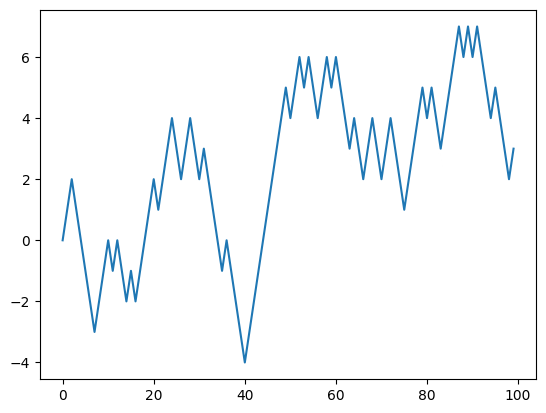

In [181]:
from matplotlib import pyplot as plt
plt.plot(walk[:100])

你可能会注意到，行走是随机步数的累积和，可以作为一个数组表达式来评估。因此，我使用numpy.random模块一次性抽取1000次硬币翻转，将这些设置为1和-1，并计算累积和：

In [182]:
nsteps = 1000
rng = np.random.default_rng(seed=12345)
draws = rng.integers(0, 2, size=nsteps)
steps = np.where(draws > 0, 1, -1)
walk = steps.cumsum()

由此我们可以开始提取沿行走轨迹的最小值和最大值等统计数据：

In [183]:
walk.min()

np.int64(-50)

In [184]:
walk.max()

np.int64(8)

一个更复杂的统计量是首次穿越时间，即随机游走达到特定值的步骤。在这里，我们可能想知道随机游走至少需要多长时间才能从原点0向任一方向移动10步。np.abs(walk) >= 10会给我们一个布尔数组，指示行走已经到达或超过了10，但我们想要的是第一个10或-10的索引。事实证明，我们可以使用argmax来计算这个值，它返回布尔数组中最大值（True是最大值）的第一个索引：

In [185]:
(np.abs(walk) >= 10).argmax()

np.int64(155)

请注意，使用argmax在这里并不总是高效的，因为它总是会遍历整个数组。在这个特殊情况下，一旦观察到True，我们就知道它是最大值。

### 同时模拟多次随机游走

如果你的目标是模拟许多随机游走，比如说五千个，你可以通过稍微修改前面的代码来生成所有的随机游走。如果传递一个2元组，numpy.random函数将生成一个二维数组，我们可以计算每一行的累积和，一次性计算出所有五千个随机游走：

In [186]:
nwalks = 5000
nsteps = 1000
draws = rng.integers(0, 2, size=(nwalks, nsteps))
steps = np.where(draws > 0, 1, -1)
walks = steps.cumsum(axis=1)

walks

array([[  1,   2,   3, ...,  22,  23,  22],
       [  1,   0,  -1, ..., -50, -49, -48],
       [  1,   2,   3, ...,  50,  49,  48],
       ...,
       [ -1,  -2,  -1, ..., -10,  -9, -10],
       [ -1,  -2,  -3, ...,   8,   9,   8],
       [ -1,   0,   1, ...,  -4,  -3,  -2]], shape=(5000, 1000))

现在我们可以计算在所有路径上获得的最大值和最小值：

In [187]:
walks.max()

np.int64(114)

In [188]:
walks.min()

np.int64(-120)

在这些散步中，让我们计算到达30或-30的最小穿越时间。这有点棘手，因为并非所有的5000次都能达到30。我们可以使用any方法来检查这一点：

In [189]:
hits30 = (np.abs(walks) >= 30).any(axis=1)

hits30

array([False,  True,  True, ...,  True, False,  True], shape=(5000,))

In [191]:
hits30.sum()

np.int64(3395)

我们可以使用这个布尔数组来选择实际穿过绝对30级的步行行，并调用argmax沿轴1获取穿越时间：

In [192]:
crossing_times = (np.abs(walks[hits30]) >= 30).argmax(axis=1)

crossing_times

array([201, 491, 283, ..., 219, 259, 541], shape=(3395,))

最后我们计算平均最小穿越时间：

In [193]:
crossing_times.mean()

np.float64(500.5699558173785)

请随意尝试其他分布的步骤，而不仅仅是等大小的硬币翻转。你只需要使用不同的随机生成器方法，比如standard_normal来生成具有某些均值和标准差的正态分布步骤：

In [194]:
draws = 0.25 * rng.standard_normal((nwalks, nsteps))

> 请记住，这种向量化方法需要创建一个包含nwalks * nsteps个元素的数组，对于大型模拟可能会占用大量内存。如果内存更受限制，则需要采用不同的方法。